# 스냅스케일 인턴십 기술 과제

## 과제 1 — P&ID 이해

**왜 이걸 하나:** 우리 일의 출발점은 도면(P&ID/PFD)을 "구조(그래프)"로 이해하는 것입니다.
무엇이 장비고, 무엇이 배관(라인)이고, 무엇이 계장이며, 무엇과 무엇이 연결되어 있는지를 사람이
읽어낼 수 있어야 합니다. 실무에선 AI가 늘 옆에 있지 않으므로, **여러분이 도면을 스스로 이해할 수
있는지**를 봅니다.

**샘플 도면 (공개):**
- File:Pump_with_tank_pid_en.svg — Wikimedia Commons, 저작자 Con-struct, **CC BY-SA 3.0**
- 링크: https://commons.wikimedia.org/wiki/File:Pump_with_tank_pid_en.svg
- (탱크 + 펌프 + 밸브 + 계장으로 구성된 표준적인 P&ID입니다.)
- ※ 일부 뷰어/다크모드에서 SVG가 검은 배경으로 깨져 보일 수 있습니다. 그럴 땐 위 Commons
  페이지에서 보거나 일반 브라우저(흰 배경)로 열어 보세요.

배경 학습이 필요하면 다음을 참고하세요(읽어도 됩니다):
- P&ID 개요: https://en.wikipedia.org/wiki/Piping_and_instrumentation_diagram
- 계장 태그 글자 규칙(ISA S5.1)은 위 위키 문서 안에 표로 정리되어 있습니다.

### 사전 준비 (AI 사용 허용, 비중 낮음)

1. 위 도면을 **그래프 구조로 이해해서, 손으로 그래프를 그려오세요.**
   - 노드 = 장비/계장(예: 탱크, 펌프, 밸브, 계장 버블)
   - 엣지 = 공정 라인 연결 / 계장 신호 연결 (둘을 구분해서 표시)
   - 종이에 그려 **사진을 찍어 제출**하면 됩니다(깔끔할 필요 없음).
2. 짧은 노트(1쪽 이내):
   - 주요 심볼이 각각 무엇인지
   - 공정 흐름을 처음부터 끝까지 **트레이스**(어디서 들어와 어디로 나가는지)
   - **제어 루프(control loop)** 가 무엇이고 어떻게 동작하는지
   - "어디부터 어디까지를 한 라인으로 볼 것인가", "교차점이 연결인가 비연결인가" 같은 **당신의
     판단과 그 근거**

### 라이브 평가 (라이브 리뷰 세션에서, AI·검색 없이 진행)

사전 제출물은 준비를 돕기 위한 것이고, **점수의 핵심은 리뷰 세션에서 AI 없이 도면을 이해하고
설명하는 능력**입니다. 리뷰 세션에서는 예를 들어 이런 것을 즉석에서 요청할 수 있습니다.

- 도면의 일부를 화이트보드/종이에 다시 그려보기
- 특정 흐름 트레이스 (예: "이 밸브가 닫히면 어디가 영향받나")
- 계장 태그 해독 (예: 태그의 각 글자가 무슨 뜻이고 무엇을 측정/제어하나)
- 약간 변형된 상황 추론 (예: "여기에 펌프를 하나 더 병렬로 붙이면 네 그래프에서 무엇이 바뀌나")

> 준비할 때 AI로 도면을 학습하는 것은 권장합니다. 다만 라이브에서는 **스스로** 설명할 수 있어야
> 합니다.

---

## 과제 1 — P&ID 이해 노트

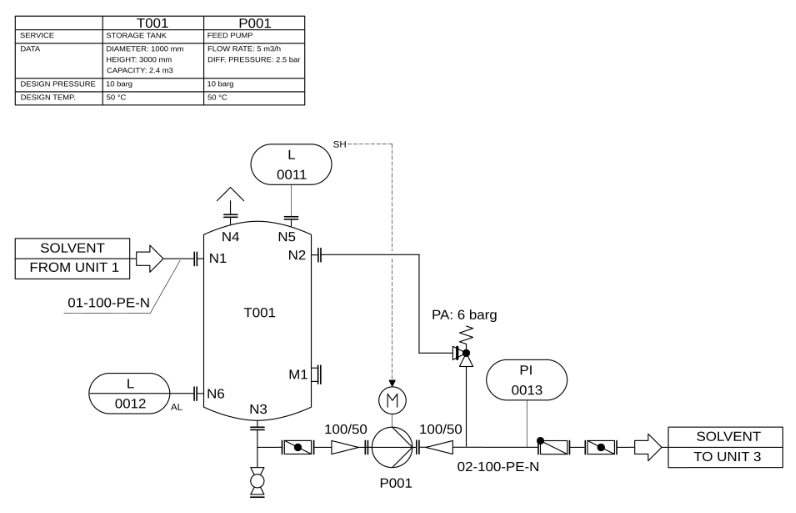

#### 1. 주요 심볼 정리

* **T001**: 용매를 저장하는 탱크이다. 공정 유체가 유입되고 일정 수위 이상이 되면 펌프를 통해 다음 공정으로 이송된다.
* **P001**: 탱크 하부에서 배출된 용매를 UNIT 3 방향으로 보내는 펌프이다.
* **M1**: 탱크 내부 점검, 정비, 청소를 위한 출입구로 판단했다.
* **N1~N6**: 탱크에 연결된 노즐이다. 각각 유입, 배출, 벤트, 계장 연결, 압력 보호 또는 수위 감지 용도로 해석했다.
* **Ball valve / Butterfly valve**: 배관을 열고 닫아 유체 흐름을 차단하거나 허용하는 수동 밸브로 보았다.
* **Check valve**: 펌프 후단에서 역류를 방지하는 밸브이다. 정상 방향 흐름은 통과시키고, 반대 방향 흐름은 차단한다.(압력에 의한 동작)
* **Relief valve**: 탱크 또는 배관의 압력이 과도하게 상승할 때 압력을 방출하는 보호 장치로 판단했다.
* **L0011**: High Level Switch로 해석했다. 탱크 수위가 높아지면 펌프 구동 신호를 보내는 계장이다.
* **L0012**: Low Level Switch로 해석했다. 탱크 수위가 낮아지면 알람을 발생시키는 계장이다.
* **PI0013**: Pressure Indicator로 해석했다. 탱크 또는 연결 배관의 압력을 현장에서 확인하는 계기이다.

#### 2. 공정 흐름 트레이스

용매는 **SOLVENT FROM UNIT 1**에서 시작해 배관을 따라 탱크 **T001**의 유입 노즐 **N1**으로 들어간다.   
탱크에 용매가 저장되고, 일정 수위 이상이 되면 **L0011**이 High Level 상태를 감지한다.   
이 신호에 따라 모터 또는 펌프 구동 조건이 만족되고, 탱크 하부 배출 노즐을 통해 용매가 **P001 펌프**로 이동한다.

펌프는 용매에 압력을 가해 **SOLVENT TO UNIT 3** 방향으로 이송한다.   
펌프 후단에는 역류 방지를 위한 체크 밸브가 있어, 펌프 정지 또는 후단 압력 상승 시 유체가 탱크 방향으로 되돌아가는 것을 막는다.

탱크 상부의 **N4**는 가스 배출 또는 벤트 라인으로 보았다.   
운전 중 탱크 내부 압력이 상승하거나 기체가 발생할 경우, 해당 라인을 통해 압력 또는 가스를 배출할 수 있다.

#### 3. 제어 루프 동작

이 도면의 핵심 제어는 **탱크 수위에 따른 펌프 운전 제어**로 판단했다.

1. 탱크 T001에 용매가 유입된다.
2. 수위가 높아져 L0011이 High Level을 감지한다.
3. L0011의 신호에 따라 펌프 P001이 구동된다.
4. 펌프는 탱크의 용매를 UNIT 3으로 이송한다.
5. 탱크 수위가 낮아지면 L0012가 Low Level 상태를 감지한다.
6. L0012는 알람을 발생시켜 운전자가 낮은 수위 상태를 인지하도록 한다.

압력 측면에서는 PI0013을 통해 압력을 확인하고, 압력이 비정상적으로 상승할 경우 relief valve 또는 관련 보호 계통이 작동하는 구조로 이해했다. 설계 압력 10 barg와 알람 또는 보호 설정값 6 barg는 서로 다른 의미로 보았다. 10 barg는 장비가 견딜 수 있도록 설계된 기준 압력이고, 6 barg는 실제 운전 중 이상 상태를 조기에 감지하거나 보호 동작을 시작하기 위한 운전 기준값으로 판단했다.

#### 4. 라인 구분과 연결 판단

공정 라인과 계장 신호 라인은 구분해서 해석했다. 굵은 실선은 실제 유체가 흐르는 **공정 배관**으로 보고, 계장 버블과 장비를 연결하는 얇은 선 또는 점선은 **계장 신호 또는 측정 연결**로 보았다.

라인 번호가 같고 방향이 연속적으로 이어지는 구간은 하나의 공정 라인으로 판단했다. 반면 펌프, 밸브, 탱크 같은 주요 장비를 지나면 기능적으로 구간이 달라지므로 별도 엣지로 나누어 그래프화하는 것이 적절하다고 보았다.

실제 연결은 T자 접속, 노즐 접속, 밸브 또는 장비와 명확히 맞닿는 지점만 연결로 보았다. 만약 배관이 단순 교차하는 부분이라 연결점 표시가 없으면 비연결로 판단할 필요가 있을 것으로 예상된다. 이는 그래프 구조를 만들 때 잘못된 연결을 방지하기 위한 기준이다.

#### 5. 내가 세운 가정

* L0011은 High Level Switch이며, 펌프 구동 조건과 연결된다고 가정했다.
* L0012는 Low Level Switch이며, 저수위 알람을 발생시킨다고 가정했다.
* N4는 탱크 상부 벤트 라인으로 보았다.
* M1은 공정 흐름에 직접 관여하지 않는 점검용 출입구로 보았다.
* Ball valve와 butterfly valve는 기본적으로 수동 차단 밸브로 보았다.
* Relief valve는 정상 운전용 밸브가 아니라 과압 보호용 장치로 보았다.

#### 6. 내가 떠올린 질문과 현재 판단

**Q1. L0011이 펌프를 직접 기동시키는 구조인지, 아니면 제어 시스템(DCS/PLC)을 통해 간접적으로 기동시키는 구조인지?**

현재 도면만으로는 직접 기동인지 간접 기동인지 판단할 수 없다.   
도면에서는 L0011(SH)에서 모터(M)로 점선 신호가 연결되어 있으므로, 고수위 발생 시 펌프 운전과 관련된 신호를 전달하는 것으로 보인다.   
실제 플랜트에서는 계장 스위치가 모터를 직접 구동하기보다는 PLC 또는 DCS를 거쳐 기동 명령을 내리는 경우가 일반적이다.   


**Q2. PA: 6 barg 설정값은 단순 알람 발생 조건인지, 실제 Relief Valve 개방 압력인지?**

도면에는 "PA : 6 barg"라고만 표시되어 있으며 Relief Valve의 Set Pressure라는 명확한 표기가 없다.   
따라서 현재 정보만으로는 다음 두 가지 가능성이 존재한다.

1. Pressure Alarm (압력 알람)
2. Pressure Relief Valve 개방 압력

그러나 태그명이 PA(Pressure Alarm)로 보이므로 압력이 6 barg 이상일 때 알람을 발생시키는 설정값으로 해석하는 것이 더 타당하다고 판단하였다.


**Q3. N2의 정확한 역할은 무엇인가?**

N2는 탱크 내부 압력을 외부 계장 계통으로 전달하는 노즐(Nozzle)로 보인다.   
N2를 통해 연결된 계통에는 PI0013(Pressure Indicator)과 PA:6 barg가 존재하므로 압력 측정 및 감시 기능을 수행하는 것으로 판단하였다.   
따라서 N2 자체가 Relief Valve는 아니며, 압력 계장 장치가 연결되는 인터페이스 역할을 수행한다고 보았다.


**Q4. 펌프 전단 또는 후단 밸브가 닫힌 상태에서 펌프가 기동될 경우 어떤 보호 기능이 존재하는가?**

현재 도면에는 인터록(Interlock) 또는 트립(Trip) 조건이 표시되어 있지 않다.   
만약 흡입측 밸브가 닫힌 상태에서 펌프가 기동되면 Dry Run이 발생할 수 있으며, 토출측 밸브가 닫힌 상태에서 기동되면 Dead Head 상태가 발생하여 압력이 급격히 상승할 수 있다.   
실제 플랜트에서는 이러한 상황을 방지하기 위해 저유량 보호, 압력 스위치, 모터 보호 계전기 등의 인터록이 존재할 가능성이 높다.


**Q5. 배관 직경이 100 → 50 → 100으로 변화하는 이유는 무엇인가?**

도면상 배관 번호는 DN100으로 보이지만 펌프 전후단에는 100/50 Reducer가 표시되어 있다.   
이는 일반적으로 펌프 노즐 크기와 주배관 크기가 다를 때 사용된다.   
따라서 유량 제어 목적이라기보다는 펌프의 흡입·토출 노즐 규격에 맞추기 위한 배관 연결부로 판단하였다.   

**Q6. UNIT1에서 지속적으로 용매가 공급되면 T001은 어떻게 Overflow를 방지하는가?**

도면에는 L0011(고수위 스위치)은 존재하지만 유입 라인을 차단하는 Control Valve는 표시되어 있지 않다.   
따라서 현재 도면만으로는 Overflow Protection이 완전히 표현되어 있다고 보기 어렵다.   
가능한 시나리오는 다음과 같다.   

1. L0011 신호로 펌프를 기동하여 탱크를 비운다.
2. 상위 제어 시스템(DCS/PLC)이 UNIT1 공급을 차단한다.
3. 실제 설비에는 추가적인 High-High Level 보호 계통이 존재하지만 본 도면에서는 생략되었다.


**Q7. Relief Valve가 존재한다면 압력은 어디로 방출되는가?**

현재 도면에는 Relief Valve 이후의 배출 라인이 표시되어 있지 않다.   
일반적인 플랜트에서는 Relief Valve가 개방되면 다음 중 하나로 연결된다.   

1. 대기(Vent)
2. Flare Header
3. Recovery System

그러나 본 도면에서는 해당 배관이 존재하지 않으므로 방출 위치와 유체 경로를 판단할 수 없다.   
따라서 현재 도면만으로는 Relief Valve의 존재 여부와 방출 목적지를 확정할 수 없으며, 추가 P&ID 또는 배관 도면 확인이 필요하다.


**Q8. 체크밸브는 왜 필요한가?**

펌프 정지 시 UNIT3 측 압력이 더 높으면 토출측 유체가 탱크 방향으로 역류할 수 있다.   
이 경우 펌프 역회전, 탱크 수위 변화, 압력 불안정 등의 문제가 발생할 수 있다.
체크밸브는 정상 방향 흐름만 허용하고 역류를 방지한다.   
따라서 탱크 보호와 펌프 보호를 위해 설치된 것으로 판단하였다.   


**Q9. N4(Vent)의 역할은 무엇인가?**

탱크는 액체가 채워지거나 배출될 때 내부 기체 공간이 변한다.
벤트가 없다면 탱크 충전 시 내부 압력이 상승, 탱크 배출 시에는 진공이 형성될 수 있다.
따라서 N4는 탱크 내부 압력 평형을 유지하기 위한 통기(Vent) 역할로 판단하였다.


**Q10. L0012(Low Level Alarm)가 있는데 펌프 정지 기능은 왜 없는가?**

도면에는 Alarm만 표시되어 있다.   
실제 플랜트에서는 Low-Low Level에서 펌프 정지 인터록이 존재할 가능성이 높다.   
그러나 본 도면은 교육용으로 단순화되어 일부 보호 로직이 생략된 것으로 판단하였다.

**Q11. Pump P001이 정지되면 공정 전체는 어떻게 되는가?**

UNIT1에서 계속 유입이 발생하면 탱크 수위가 증가한다.   
펌프가 장시간 정지되면 Overflow 위험이 존재한다.   
따라서 실제 설비에서는 경보 또는 공급 차단 로직이 있을 것으로 예상된다.
(이 시스템에서 가장 위험한 고장 시나리오로 예상된다.)


**Q12. Ball Valve와 Butterfly Valve를 왜 구분해서 사용했는가?**

Ball Valve는 완전 차단 성능이 우수하다.   
Butterfly Valve는 대구경 배관에서 설치 공간과 비용 측면에서 유리하다.   
실제 설계 의도는 알 수 없으나 일반적인 플랜트 설계 원칙과 유사하다고 판단하였다.


**Q13. 가장 위험한 단일 밸브 고장은 무엇인가?**

토출측 Butterfly Valve가 닫힌 상태에서 펌프가 계속 운전되는 경우이다.   
Dead Head 상태가 발생하여 펌프 손상 또는 압력 상승 위험이 있다.


**Q14. 왜 압력은 측정하지만 유량은 측정하지 않는가?**

도면에는 Pressure Indicator만 존재한다.   
Flow Meter 또는 Flow Indicator는 표시되어 있지 않다.   
교육용 예제이기 때문에 단순화되었거나 유량 계측이 필요 없는 공정일 가능성이 있다.


**Q15. 이 도면을 온톨로지로 만든다면 어떤 클래스가 필요한가?**

최소한 다음 클래스가 필요하다.

* Equipment
* Pump
* Tank
* Valve
* Instrument
* Nozzle
* ProcessLine
* SignalLine
* Alarm